## Task 1: k-Fold Cross-Validation

In [63]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import sklearn
np.random.seed(42)

In [64]:
x = np.random.uniform(-2,2,120)
y = 1+0.8*x-1.5*x**2+0.5*x**3+ np.random.normal(0,0.3,120)

In [65]:
x

array([-0.50183952,  1.80285723,  0.92797577,  0.39463394, -1.37592544,
       -1.37602192, -1.76766555,  1.46470458,  0.40446005,  0.83229031,
       -1.91766202,  1.87963941,  1.32977056, -1.15064356, -1.27270013,
       -1.26638196, -0.78303103,  0.09902573, -0.27221993, -0.83508344,
        0.44741158, -1.44202456, -0.83142141, -0.53455263, -0.17572006,
        1.14070385, -1.20130487,  0.05693775,  0.36965828, -1.81419835,
        0.43017941, -1.31790351, -1.73979363,  1.79554215,  1.86252813,
        1.23358939, -0.78154492, -1.60931154,  0.73693211, -0.23939003,
       -1.51184706, -0.01929236, -1.86244592,  1.63728161, -0.96488007,
        0.65008914, -0.7531557 ,  0.08027208,  0.18684112, -1.26058218,
        1.87833851,  1.10053129,  1.75799577,  1.5793094 ,  0.39159992,
        1.68749694, -1.64602999, -1.21606855, -1.81909084, -0.69867868,
       -0.44529084, -0.91460387,  1.31495004, -0.57298669, -0.87626196,
        0.17078433, -1.4363031 ,  1.20878792, -1.70179743,  1.94

In [66]:
y

array([ -0.05304427,   0.39845404,   0.7325977 ,   0.67377809,
        -4.15409142,  -4.16536037,  -7.86122123,   0.45450721,
         0.68665731,   0.78884464,  -9.67911708,   0.28388654,
         0.53870594,  -2.54698535,  -2.91269073,  -3.38178024,
        -0.70891897,   1.04266319,   0.08535091,  -1.01324615,
         1.12051343,  -4.03309729,  -1.04710257,   0.15782906,
         0.79998121,   0.35229669,  -2.64971873,   1.26635954,
         1.35332174,  -8.6466981 ,   1.52720361,  -4.2246959 ,
        -7.38917547,   1.15200145,   0.21991037,   0.47297089,
        -0.75024792,  -6.40728222,   0.50984573,   0.73623606,
        -5.68449152,   1.12608196,  -9.19897872,   0.9482921 ,
        -1.85251895,   0.92689802,  -0.42294598,   0.68555158,
         1.16860774,  -3.0014991 ,   0.04172773,   0.78552626,
         0.56512391,   0.72623822,   0.742195  ,   0.08508857,
        -6.45425258,  -3.00116842,  -8.3535311 ,  -0.35776698,
         0.098187  ,  -1.29929054,   0.68307722,  -0.25

In [67]:
from sklearn.model_selection import cross_val_score, train_test_split,KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


In [68]:
X_cv, X_test, Y_cv, Y_test = train_test_split(x,y, train_size=0.8, random_state=42)
degree = [1,2,3,5,9]
k_value = [5,10]
results = {5:[],10:[]}

In [69]:
X_cv = X_cv.reshape(-1,1)
X_test = X_test.reshape(-1,1)

In [70]:
for k in k_value:
    kf = KFold(n_splits=k,shuffle=True,random_state=42)
    for p in degree:
        pipeline = make_pipeline(PolynomialFeatures(degree=p,include_bias=False),LinearRegression())
        scores = cross_val_score(pipeline, X_cv,Y_cv,cv=kf,scoring='neg_mean_squared_error')
        mean_cv = - np.mean(scores)
        results[k].append(mean_cv)
        print(f"k={k} degree = {p} scores = {mean_cv}")

k=5 degree = 1 scores = 3.857343778612864
k=5 degree = 2 scores = 0.5025791881489547
k=5 degree = 3 scores = 0.09247889284280113
k=5 degree = 5 scores = 0.09559105887972523
k=5 degree = 9 scores = 0.12311046857947441
k=10 degree = 1 scores = 3.8638177149350477
k=10 degree = 2 scores = 0.5025386254636816
k=10 degree = 3 scores = 0.09323771441961906
k=10 degree = 5 scores = 0.09516984818556447
k=10 degree = 9 scores = 0.10513726047950803


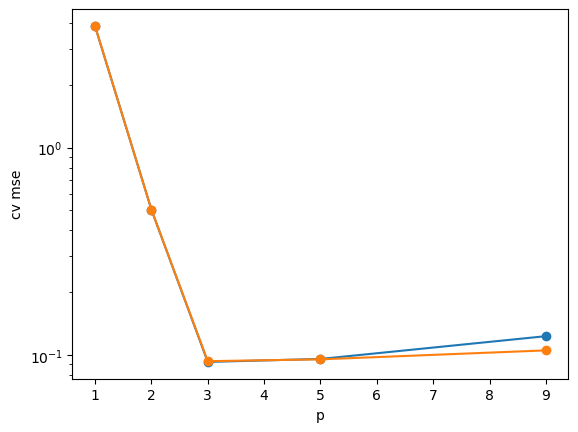

In [71]:
for k in k_value:
    plt.plot(degree,results[k],marker = 'o',label = k)
plt.yscale('log')
plt.xlabel('p')
plt.ylabel('cv mse')
plt.show()

Models with degree 1 and 2 have a high error because they are too simple (underfitting). Degree 3 gives the lowest error and fits the data best. Degrees 5 and 9 do not improve the error and just make the model too complex (risk of overfitting).

The errors for 5-fold and 10-fold cross-validation are almost the exact same. 10-fold trains on slightly more data in each step but takes more time to run. Since the results are so similar, 5-fold is a better choice here because it is faster.

Final Model (Degree 3)
Train MSE (on X_cv): 0.0846
Test MSE (on X_test): 0.0945


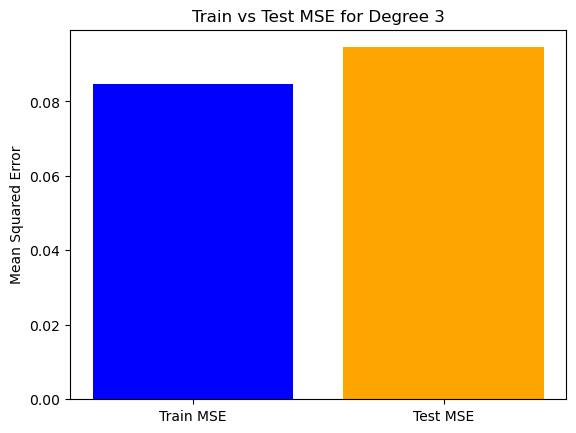

In [72]:
best_degree = 3
best_pipeline = make_pipeline(PolynomialFeatures(degree=best_degree, include_bias=False), LinearRegression())
best_pipeline.fit(X_cv, Y_cv)
Y_cv_pred = best_pipeline.predict(X_cv)
Y_test_pred = best_pipeline.predict(X_test)
train_mse = mean_squared_error(Y_cv, Y_cv_pred)
test_mse = mean_squared_error(Y_test, Y_test_pred)

print(f"Final Model (Degree {best_degree})")
print(f"Train MSE (on X_cv): {train_mse:.4f}")
print(f"Test MSE (on X_test): {test_mse:.4f}")

plt.bar(['Train MSE', 'Test MSE'], [train_mse, test_mse], color=['blue', 'orange'])
plt.ylabel('Mean Squared Error')
plt.title(f'Train vs Test MSE for Degree {best_degree}')
plt.show()

## Task 2: Regression with k-Fold Cross-Validation on a Real Dataset

In [73]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
diabetes = load_diabetes()
x= diabetes.data
y = diabetes.target
pipeline = make_pipeline(StandardScaler(),LinearRegression())

def evaluate_kfold (x,y,k):
    kf = KFold(n_splits=k,shuffle=True,random_state=42)
    scores = cross_val_score(pipeline,x,y,cv=kf,scoring='neg_mean_squared_error')
    mse_score = -1 * scores
    cv_mean = np.mean(mse_score)
    cv_std = np.std(mse_score,ddof = 1)
    return mse_score, cv_mean, cv_std
    
mses_5, cv_mean_5, cv_std_5 = evaluate_kfold(x, y, k=5)
print("5-Fold Cross-Validation:")
for i, mse in enumerate(mses_5, 1):
    print(f"Fold {i} MSE: {mse:.2f}")
print(f"Mean CV MSE: {cv_mean_5:.2f}")
print(f"Standard Deviation of MSEs: {cv_std_5:.2f}\n")

mses_10, cv_mean_10, cv_std_10 = evaluate_kfold(x, y, k=10)
print("10-Fold Cross-Validation:")
for i, mse in enumerate(mses_10, 1):
    print(f"Fold {i} MSE: {mse:.2f}")
print(f"Mean CV MSE: {cv_mean_10:.2f}")
print(f"Standard Deviation of MSEs: {cv_std_10:.2f}")
    

5-Fold Cross-Validation:
Fold 1 MSE: 2900.19
Fold 2 MSE: 2662.64
Fold 3 MSE: 3312.31
Fold 4 MSE: 2797.88
Fold 5 MSE: 3403.89
Mean CV MSE: 3015.38
Standard Deviation of MSEs: 325.62

10-Fold Cross-Validation:
Fold 1 MSE: 2743.91
Fold 2 MSE: 2979.19
Fold 3 MSE: 2427.07
Fold 4 MSE: 2943.53
Fold 5 MSE: 3649.95
Fold 6 MSE: 2941.18
Fold 7 MSE: 2408.52
Fold 8 MSE: 3170.74
Fold 9 MSE: 3485.68
Fold 10 MSE: 3486.78
Mean CV MSE: 3023.66
Standard Deviation of MSEs: 430.71


The mean CV MSE for 5-fold (≈3015.38) and 10-fold (≈3023.66) are almost the same, so both give a similar estimate of the model's error.

However, 10-fold has a higher standard deviation (≈430.71) than 5-fold (≈325.62), since smaller validation folds make the MSE noisier across folds.

5-fold trains on 80% of the data per fold, while 10-fold trains on 90%, so 10-fold uses slightly more training data but gives a noisier estimate.

CV is more informative than a single split because it averages performance over multiple random partitions instead of relying on just one, giving a more stable estimate and also showing how much that estimate varies (via the standard deviation)

## Task 3: Leave-One-Out Cross-Validation

In [74]:
np.random.seed(42)
a= 5
n = 12
w = np.random.normal(0,1,n)
x = a+ w
a_hat = np.mean(x)
print("a_hat is : ",a_hat)

a_loo =[]
error =[]
for i in range (n):
    x_without_i = np.delete(x,i)
    a_i = np.mean(x_without_i)
    a_loo.append(a_i)
    e2 = (x[i]-a_i)**2
    error.append(e2)
cv_loo = np.mean(error)

for i in range(n):
    print(f"i = {i+1} : a_i = {a_loo[i]:.4f},e^2 = {error[i]:.4f}")
print("cv_loo: ",cv_loo)

a_hat is :  5.295955305883737
i = 1 : a_i = 5.2777,e^2 = 0.0480
i = 2 : a_i = 5.3354,e^2 = 0.2244
i = 3 : a_i = 5.2640,e^2 = 0.1472
i = 4 : a_i = 5.1844,e^2 = 1.7919
i = 5 : a_i = 5.3441,e^2 = 0.3344
i = 6 : a_i = 5.3441,e^2 = 0.3344
i = 7 : a_i = 5.1793,e^2 = 1.9598
i = 8 : a_i = 5.2531,e^2 = 0.2645
i = 9 : a_i = 5.3655,e^2 = 0.6972
i = 10 : a_i = 5.2735,e^2 = 0.0724
i = 11 : a_i = 5.3650,e^2 = 0.6863
i = 12 : a_i = 5.3652,e^2 = 0.6904
cv_loo:  0.6042488622845181


The full-data estimate (A_hat ≈ 5.296) is very close to A = 5, and each A_-i is also close to it, since removing just one of 12 points barely changes the mean.

LOOCV has n=12 folds because each fold leaves out exactly one observation and trains on the remaining 11.

The A_-i values are all similar to each other because each leave-one-out sample differs from the others by only a single point.

LOOCV is more computationally expensive than k-fold CV since it needs n=12 refits here, compared to just k=5 or k=10 refits in ordinary k-fold CV.

## Task 4: Bootstrap Method

paired diff :  [3 3 1 4 2 2 4 1]
Sample mean d_bar : 2.5
Bootstrap mean S_star :  2.5005
Bootstarp Variance: 0.1616926926926927
Bootstrap Standard Derivation:  0.40211029916267094


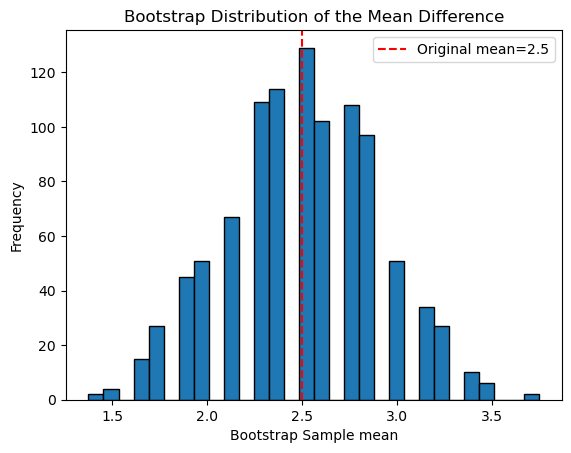

In [75]:
np.random.seed(42)
before = np.array([18,21,16,24,20,19,23,17])
after = np.array([15,18,15,20,18,17,19,16])
d = before - after
d_mean = np.mean(d)
print ("paired diff : ",d)
print("Sample mean d_bar :" ,d_mean)

n = len(d)
B = 1000
boot_means=[]
for b in range (B):
    sample = np.random.choice(d,size=n,replace= True)
    boot_means.append(np.mean(sample))
boot_means = np.array(boot_means)
S_star = np.mean(boot_means)
var_boot = np.var(boot_means,ddof = 1)
sd_boot = np.std(boot_means,ddof =1 )
print ("Bootstrap mean S_star : ",S_star)
print ("Bootstarp Variance:", var_boot)
print ("Bootstrap Standard Derivation: ",sd_boot)

plt.hist(boot_means,bins = 30, edgecolor='black')
plt.axvline(d_mean,color='red', linestyle='--',label = f'Original mean={d_mean}')
plt.xlabel('Bootstrap Sample mean')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution of the Mean Difference')
plt.legend()
plt.show()


The bootstrap mean (≈2.5005) is almost the same as the original sample mean (2.5), and the spread of the histogram (SD ≈ 0.402) shows the standard error — how uncertain we are about the true mean difference from just 8 observations.

Bootstrap differs from k-fold CV and LOOCV because it resamples data with replacement to estimate a statistic's variability, while CV methods split data without replacement to estimate prediction error.